1. PCA and NMF: PCA actually reduce the data with directions which max the varience and can have negative values. NMF reduces data as well but only for non negative
2. Actually good initilization avoid any unstable gredient and help to work faster
3. how can we prevent overfitiing is with using dropout and regularization, data augmentation or we can use larger dataset
4. CNN by filter can detect the image pater but MLP trat and train all input same without thinking of spitial relationship.
5. To vanish problems in gredient we can use sigmoid, which gradient become very little and and hard to update the older layers for the network
6. ResNEt make grediants pass through directly wirh skiiping the connection and also solve the vanishing gredient issue

To Summary what I have done Q1: I added RandomHorizontalFlip() to flip the images by random. Then I added randomCrop to introduce variability in the training data. Then I added Dropout layer with p=0.5 to connect completely without overfitting. then I used Steplr to adjust the learning data with reducing by 5 ephchs. I also added optimizer to with SGD momentum to improve and make it faster.




In [2]:
import os
import time

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader

from torchvision import datasets
from torchvision import transforms

import matplotlib.pyplot as plt
from PIL import Image


if torch.cuda.is_available():
    torch.backends.cudnn.deterministic = True

In [3]:
##########################
### SETTINGS
##########################

# Hyperparameters
RANDOM_SEED = 1
LEARNING_RATE = 0.001
BATCH_SIZE = 128
NUM_EPOCHS = 10

# Architecture
NUM_FEATURES = 32*32
NUM_CLASSES = 10

# Other
if torch.cuda.is_available():
    DEVICE = "cuda:0"
else:
    DEVICE = "cpu"

GRAYSCALE = False

In [4]:
##########################
### CIFAR-10 Dataset
##########################

train_mean = (0.5, 0.5, 0.5)
train_std = (0.5, 0.5, 0.5)

# Adding data augmentation for training to reduce overfitting
resize_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),  # Random horizontal flip
    transforms.RandomCrop(32, padding=4),  # Random crop
    transforms.ToTensor(),  # Convert to PyTorch tensors
    transforms.Normalize(train_mean, train_std)  # Normalize
])

# Transform for test data (no augmentation)
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(train_mean, train_std)  # Normalize
])

# Datasets
train_dataset = datasets.CIFAR10(root='data', 
                                 train=True, 
                                 transform=resize_transform,
                                 download=True)

test_dataset = datasets.CIFAR10(root='data', 
                                train=False, 
                                transform=test_transform)

# Data loaders
train_loader = DataLoader(dataset=train_dataset, 
                          batch_size=BATCH_SIZE, 
                          num_workers=8,
                          shuffle=True)

test_loader = DataLoader(dataset=test_dataset, 
                         batch_size=BATCH_SIZE,
                         num_workers=8,
                         shuffle=False)

# Checking the dataset
for images, labels in train_loader:  
    print('Image batch dimensions:', images.shape)
    print('Image label dimensions:', labels.shape)
    break

for images, labels in train_loader:  
    print('Image batch dimensions:', images.shape)
    print('Image label dimensions:', labels.shape)
    break


Files already downloaded and verified
Image batch dimensions: torch.Size([128, 3, 32, 32])
Image label dimensions: torch.Size([128])
Image batch dimensions: torch.Size([128, 3, 32, 32])
Image label dimensions: torch.Size([128])


In [5]:
device = torch.device(DEVICE)
torch.manual_seed(0)

for epoch in range(2):

    for batch_idx, (x, y) in enumerate(train_loader):
        
        print('Epoch Num:', epoch+1, end='')
        print(' | Batches Inx:', batch_idx, end='')
        print(' | The Size of Batch:', y.size()[0])
        
        x = x.to(device)
        y = y.to(device)
        

Epoch Num: 1 | Batches Inx: 0 | The Size of Batch: 128
Epoch Num: 1 | Batches Inx: 1 | The Size of Batch: 128
Epoch Num: 1 | Batches Inx: 2 | The Size of Batch: 128
Epoch Num: 1 | Batches Inx: 3 | The Size of Batch: 128
Epoch Num: 1 | Batches Inx: 4 | The Size of Batch: 128
Epoch Num: 1 | Batches Inx: 5 | The Size of Batch: 128
Epoch Num: 1 | Batches Inx: 6 | The Size of Batch: 128
Epoch Num: 1 | Batches Inx: 7 | The Size of Batch: 128
Epoch Num: 1 | Batches Inx: 8 | The Size of Batch: 128
Epoch Num: 1 | Batches Inx: 9 | The Size of Batch: 128
Epoch Num: 1 | Batches Inx: 10 | The Size of Batch: 128
Epoch Num: 1 | Batches Inx: 11 | The Size of Batch: 128
Epoch Num: 1 | Batches Inx: 12 | The Size of Batch: 128
Epoch Num: 1 | Batches Inx: 13 | The Size of Batch: 128
Epoch Num: 1 | Batches Inx: 14 | The Size of Batch: 128
Epoch Num: 1 | Batches Inx: 15 | The Size of Batch: 128
Epoch Num: 1 | Batches Inx: 16 | The Size of Batch: 128
Epoch Num: 1 | Batches Inx: 17 | The Size of Batch: 128
Ep

In [6]:
class LeNet5(nn.Module):

    def __init__(self, num_classes, grayscale=False):
        super(LeNet5, self).__init__()
        
        self.grayscale = grayscale
        self.num_classes = num_classes

        if self.grayscale:
            in_channels = 1  # Indented properly
        else:
            in_channels = 3  # Indented properly

        # Feature extractor part
        self.features = nn.Sequential(
            nn.Conv2d(in_channels, 6*in_channels, kernel_size=5),  # First convolution
            nn.ReLU(),  # ReLU activation function
            nn.MaxPool2d(kernel_size=2),  # First pooling layer
            nn.Conv2d(6*in_channels, 16*in_channels, kernel_size=5),  # Second convolution
            nn.ReLU(),  # ReLU activation function
            nn.MaxPool2d(kernel_size=2)  # Second pooling layer
        )
        
        # Classifier part
        self.classifier = nn.Sequential(
            nn.Linear(16*5*5*in_channels, 256),  # Increased size for fully connected layer 1
            nn.ReLU(),  # ReLU activation for better learning
            nn.Dropout(p=0.5),  # Dropout for regularization
            nn.Linear(256, 128),  # Increased size for fully connected layer 2
            nn.ReLU(),  # ReLU activation
            nn.Dropout(p=0.5),  # Dropout for regularization
            nn.Linear(128, num_classes)  # Output layer
        )

    def forward(self, x):
        x = self.features(x)  # Pass through feature extractor
        x = torch.flatten(x, 1)  # Flatten for fully connected layers
        logits = self.classifier(x)  # Pass through the classifier
        probas = F.softmax(logits, dim=1)  # Apply softmax for probabilities
        return logits, probas


In [7]:
torch.manual_seed(RANDOM_SEED)

model = LeNet5(NUM_CLASSES, GRAYSCALE)
model.to(DEVICE)

optimizer = torch.optim.SGD(model.parameters(), lr=0.001, momentum=0.9)

scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)
#the line in the top is for addinf schedular

In [8]:
def compute_accuracy(model, data_loader, device):
    correct_pred, num_examples = 0, 0
    for i, (features, targets) in enumerate(data_loader):
            
        features = features.to(device)
        targets = targets.to(device)

        logits, probas = model(features)
        _, predicted_labels = torch.max(probas, 1)
        num_examples += targets.size(0)
        correct_pred += (predicted_labels == targets).sum()
    return correct_pred.float()/num_examples * 100
    

start_time = time.time()
for epoch in range(NUM_EPOCHS):
    
    model.train()
    for batch_idx, (features, targets) in enumerate(train_loader):
        
        features = features.to(DEVICE)
        targets = targets.to(DEVICE)
            
        ### FORWARD AND BACK PROP
        logits, probas = model(features)
        cost = F.cross_entropy(logits, targets)
        optimizer.zero_grad()
        
        cost.backward()
        
        ### UPDATE MODEL PARAMETERS
        optimizer.step()
        
        ### LOGGING
        if not batch_idx % 50:
            print ('Epoch are becoming: %03d/%03d | And Batch have become %04d/%04d | This is Cost: %.4f' 
                   %(epoch+1, NUM_EPOCHS, batch_idx, 
                     len(train_loader), cost))

        #step to the learning rate schedular at the end of each epo
        scheduler.step()

    model.eval()
    with torch.set_grad_enabled(False): # save memory during inference
        print('Epoches are: %03d/%03d | With Taining: %.3f%%' % (
              epoch+1, NUM_EPOCHS, 
              compute_accuracy(model, train_loader, device=DEVICE)))
        
    print('The Time Elapsed: %.2f min' % ((time.time() - start_time)/60))
    
print('Output the total training time: %.2f min' % ((time.time() - start_time)/60))

Epoch are becoming: 001/010 | And Batch have become 0000/0391 | This is Cost: 2.3155
Epoch are becoming: 001/010 | And Batch have become 0050/0391 | This is Cost: 2.3106
Epoch are becoming: 001/010 | And Batch have become 0100/0391 | This is Cost: 2.3072
Epoch are becoming: 001/010 | And Batch have become 0150/0391 | This is Cost: 2.3100
Epoch are becoming: 001/010 | And Batch have become 0200/0391 | This is Cost: 2.3062
Epoch are becoming: 001/010 | And Batch have become 0250/0391 | This is Cost: 2.3051
Epoch are becoming: 001/010 | And Batch have become 0300/0391 | This is Cost: 2.3063
Epoch are becoming: 001/010 | And Batch have become 0350/0391 | This is Cost: 2.2970
Epoches are: 001/010 | With Taining: 9.536%
The Time Elapsed: 2.11 min
Epoch are becoming: 002/010 | And Batch have become 0000/0391 | This is Cost: 2.3073
Epoch are becoming: 002/010 | And Batch have become 0050/0391 | This is Cost: 2.3006
Epoch are becoming: 002/010 | And Batch have become 0100/0391 | This is Cost: 2

In [9]:
with torch.set_grad_enabled(False): # save memory during inference
    print('Test accuracy: %.2f%%' % (compute_accuracy(model, test_loader, device=DEVICE)))

Test accuracy: 9.06%


In [10]:
class UnNormalize(object):
    def __init__(self, mean, std):
        self.mean = mean
        self.std = std

    def __call__(self, tensor):
        """
        Parameters:
        ------------
        tensor (Tensor): Tensor image of size (C, H, W) to be normalized.
        
        Returns:
        ------------
        Tensor: Normalized image.

        """
        for t, m, s in zip(tensor, self.mean, self.std):
            t.mul_(s).add_(m)
        return tensor
    
unorm = UnNormalize(mean=train_mean, std=train_std)

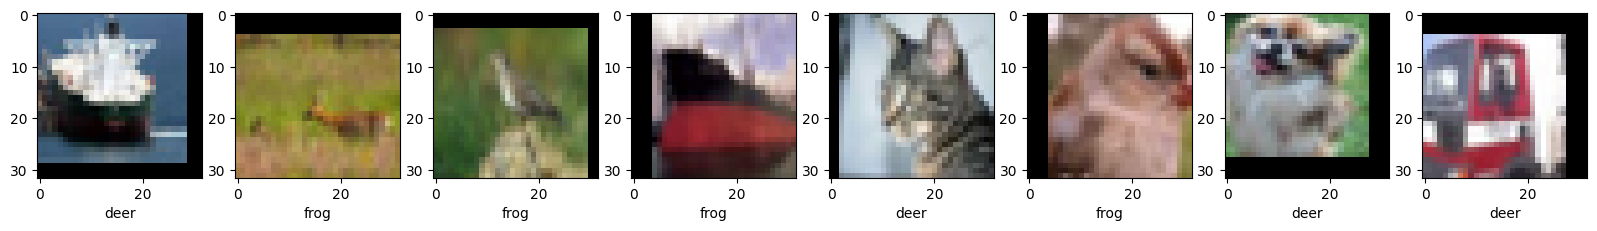

In [11]:
test_loader = DataLoader(dataset=train_dataset, 
                         batch_size=BATCH_SIZE, 
                         shuffle=True)

for features, targets in test_loader:
    break
    

_, predictions = model.forward(features[:8].to(DEVICE))
predictions = torch.argmax(predictions, dim=1)

d = {0: 'airplane',
     1: 'automobile',
     2: 'bird',
     3: 'cat',
     4: 'deer',
     5: 'dog',
     6: 'frog',
     7: 'horse',
     8: 'ship',
     9: 'truck'}
    
fig, ax = plt.subplots(1, 8, figsize=(20, 10))
for i in range(8):
    img = unorm(features[i])
    ax[i].imshow(np.transpose(img, (1, 2, 0)))
    ax[i].set_xlabel(d[predictions[i].item()])

plt.show()